In [7]:
# essential libraries for numerical operations and data manipulation
import numpy as np
import pandas as pd
# visualization libraries for plotting and charts
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# tools for data preprocessing and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# selection of ML models for experimentation
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression


KeyboardInterrupt: 

In [ ]:
df=pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.isnull().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [ ]:
# Identify any duplicate rows in the dataset
df.duplicated().sum()

0

In [ ]:
# Remove duplicate rows from the dataset to ensure data quality
df = df.drop_duplicates()

In [ ]:
# Get descriptive statistics of the dataset's numerical features
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
# Print the number of rows and columns in the dataset
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset contains 2200 rows and 8 columns.


In [ ]:
# List and count the unique crop labels in the target column
unique_crops = df['label'].unique()
print(f"Unique crop labels: {unique_crops}")
print(f"Total unique crops: {len(unique_crops)}")

Unique crop labels: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']
Total unique crops: 22


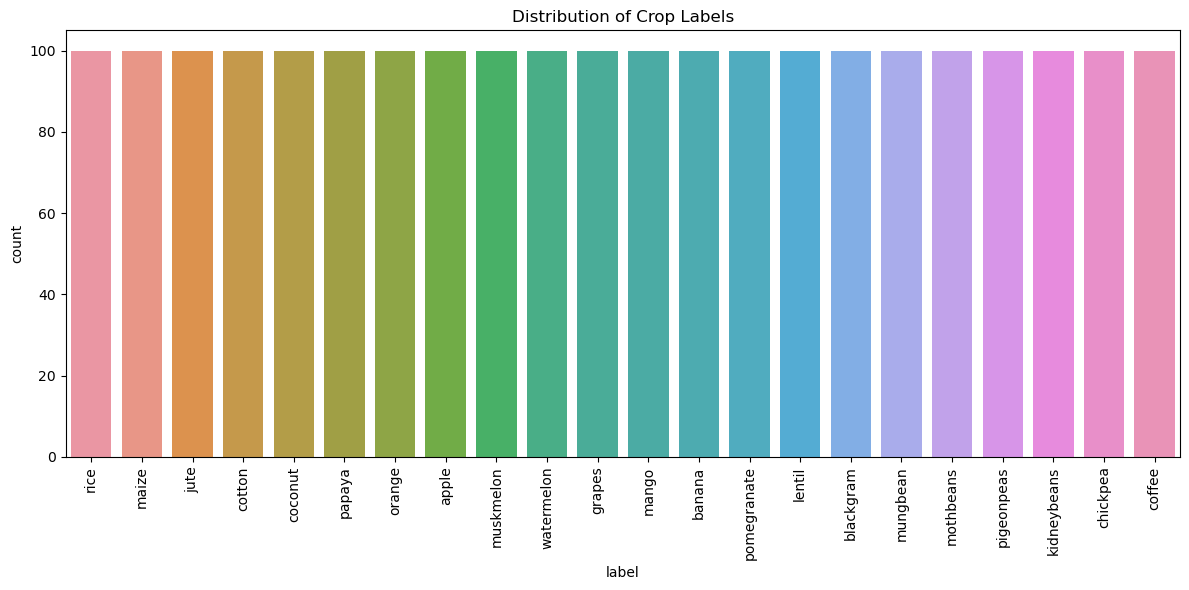

In [ ]:
# Plot the distribution of crop labels to assess class balance
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Distribution of Crop Labels')
plt.tight_layout()
plt.show()

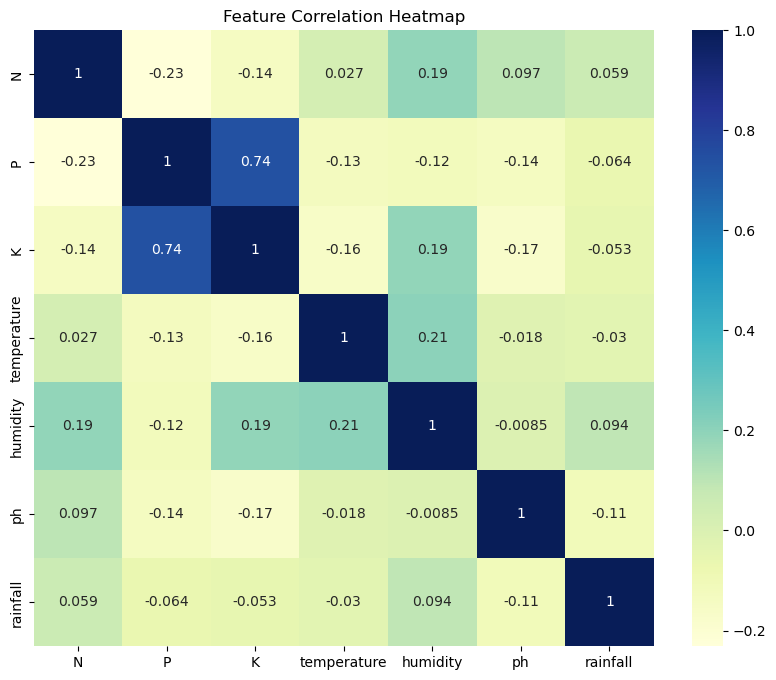

In [ ]:
# Display a heatmap to visualize correlation among numerical features (excluding non-numeric columns)
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns='label').corr(), annot=True, cmap='YlGnBu')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# Compile key dataset statistics into a summary dictionary
summary = {
    "Shape": df.shape,
    "Missing Values": df.isnull().sum().sum(),
    "Duplicates": df.duplicated().sum(),
    "Unique Labels": df['label'].nunique(),
    "Labels": list(df['label'].unique())
}
summary

{'Shape': (2200, 8),
 'Missing Values': 0,
 'Duplicates': 0,
 'Unique Labels': 22,
 'Labels': ['rice',
  'maize',
  'chickpea',
  'kidneybeans',
  'pigeonpeas',
  'mothbeans',
  'mungbean',
  'blackgram',
  'lentil',
  'pomegranate',
  'banana',
  'mango',
  'grapes',
  'watermelon',
  'muskmelon',
  'apple',
  'orange',
  'papaya',
  'coconut',
  'cotton',
  'jute',
  'coffee']}

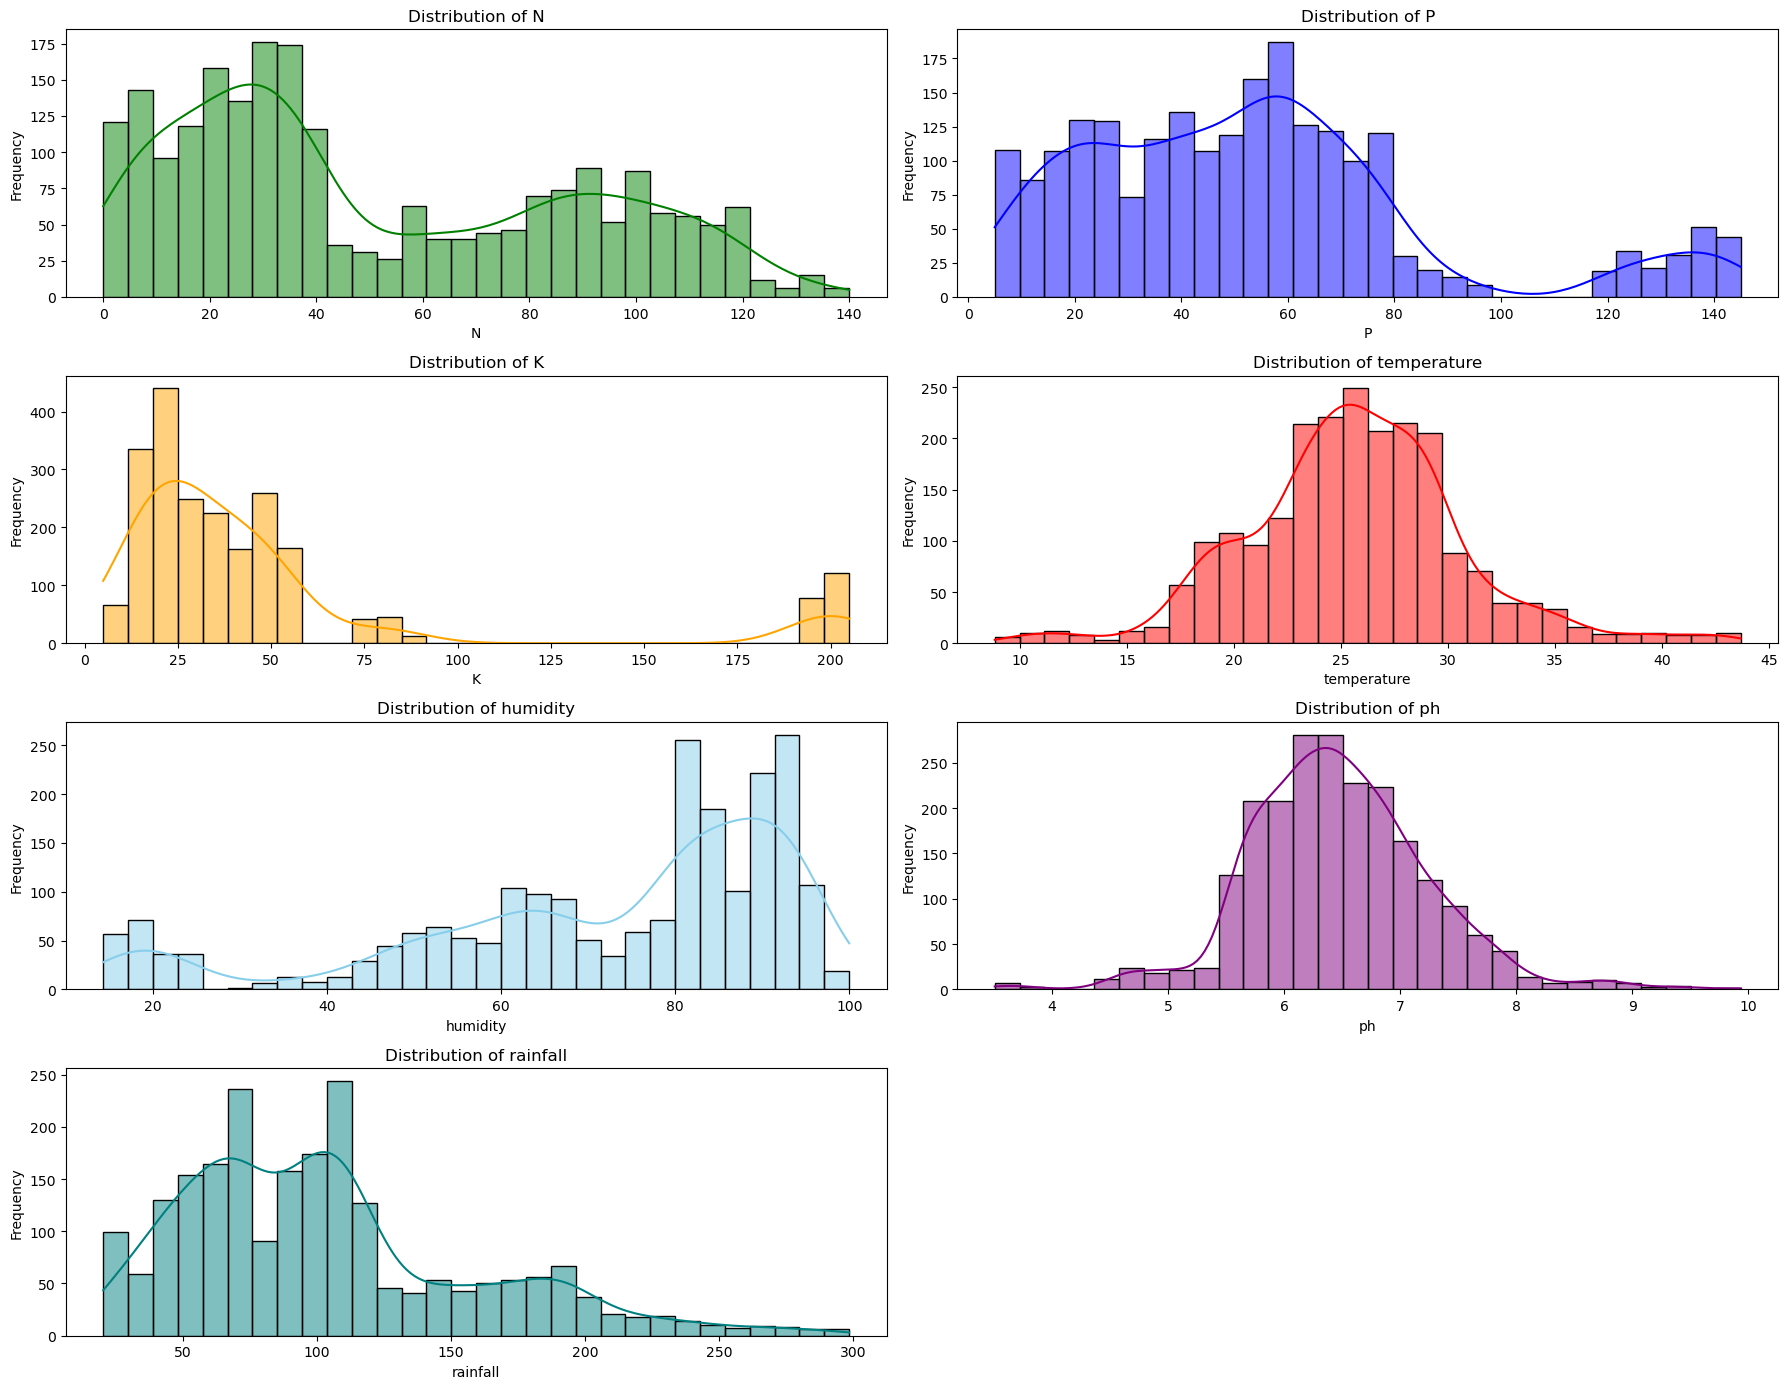

In [ ]:
# Plot the distributions of all numerical features using subplots

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
colors = ['green', 'blue', 'orange', 'red', 'skyblue', 'purple', 'teal']

plt.figure(figsize=(18, 14))
for i, feature in enumerate(features):
    plt.subplot(4, 2, i+1)
    sns.histplot(df[feature], kde=True, bins=30, color=colors[i])
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

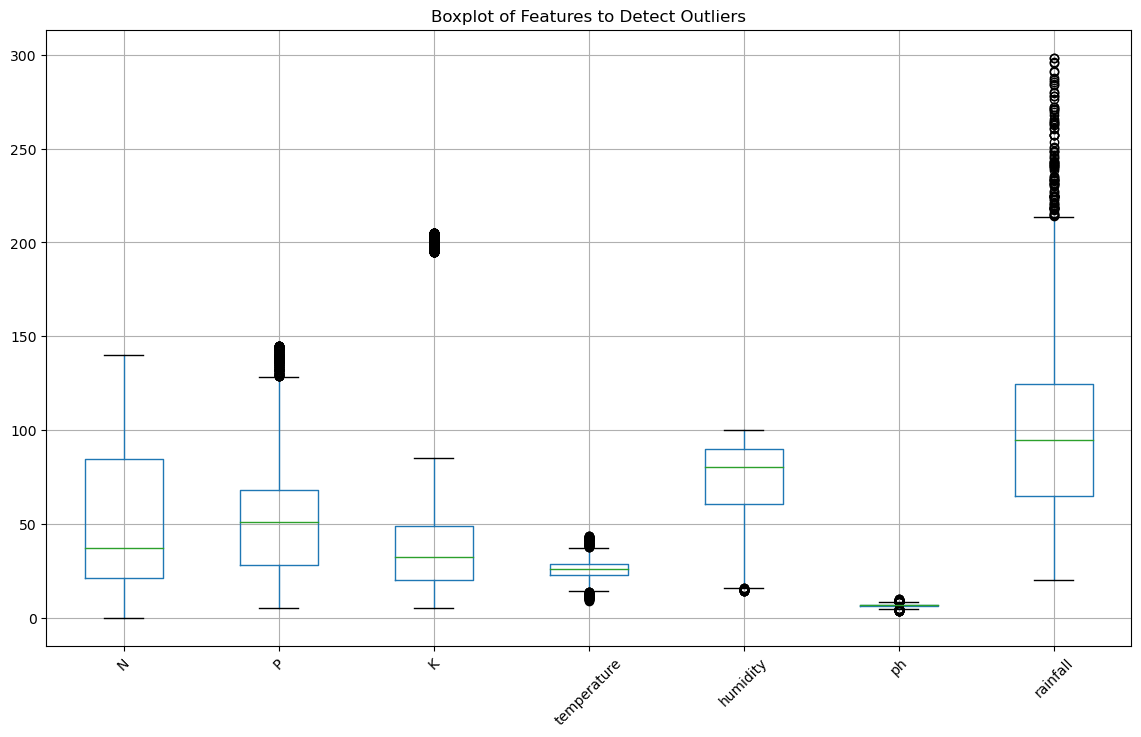

In [ ]:
# Use boxplots to detect outliers for each numeric feature
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
plt.figure(figsize=(14,8))
df[features].boxplot(rot=45)
plt.title('Boxplot of Features to Detect Outliers')
plt.show()

c:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


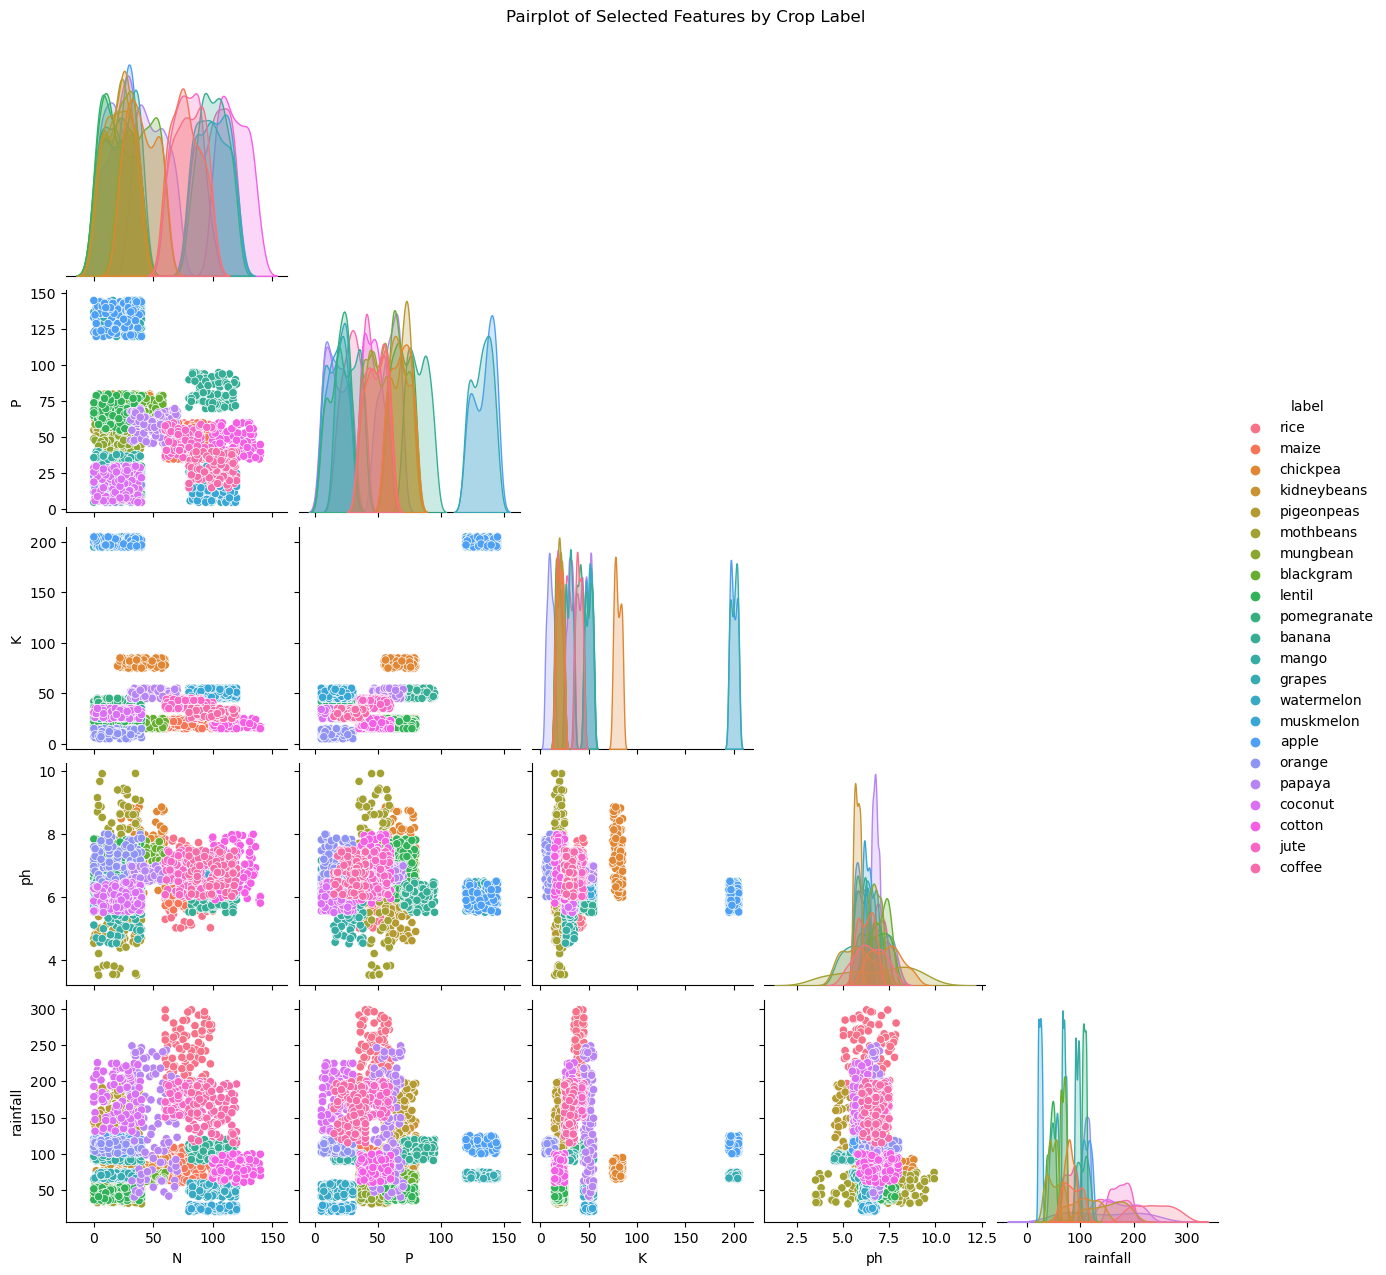

In [ ]:
# Create a pairplot of key features with hue based on crop labels
sns.pairplot(df[['N', 'P', 'K', 'ph', 'rainfall', 'label']], hue='label', diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Selected Features by Crop Label', y=1.02)
plt.show()

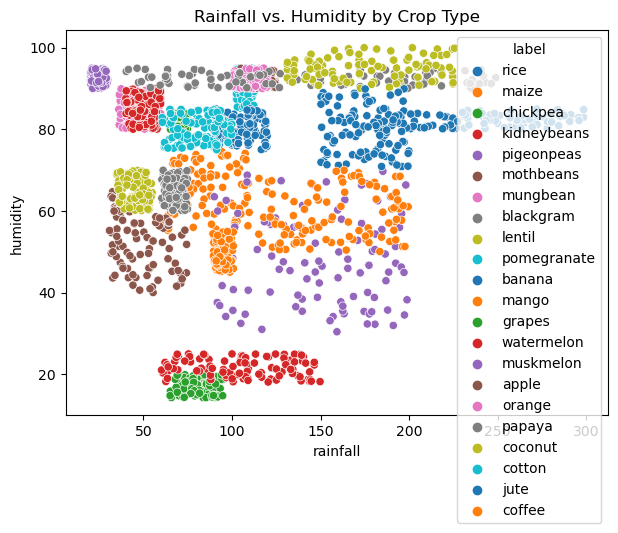

In [ ]:
# Scatter plot between rainfall and humidity
plt.figure(figsize=(7,5))
sns.scatterplot(x='rainfall', y='humidity', hue='label', data=df, palette='tab10')
plt.title('Rainfall vs. Humidity by Crop Type')
plt.show()

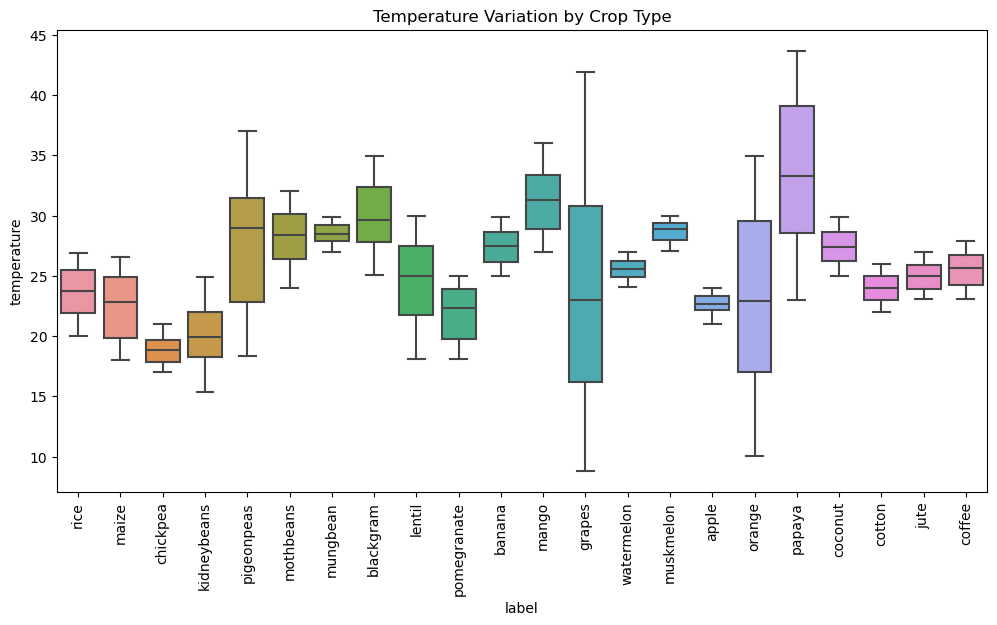

In [ ]:
# Boxplot of temperature values for different crop types
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='temperature', data=df)
plt.xticks(rotation=90)
plt.title('Temperature Variation by Crop Type')
plt.show()

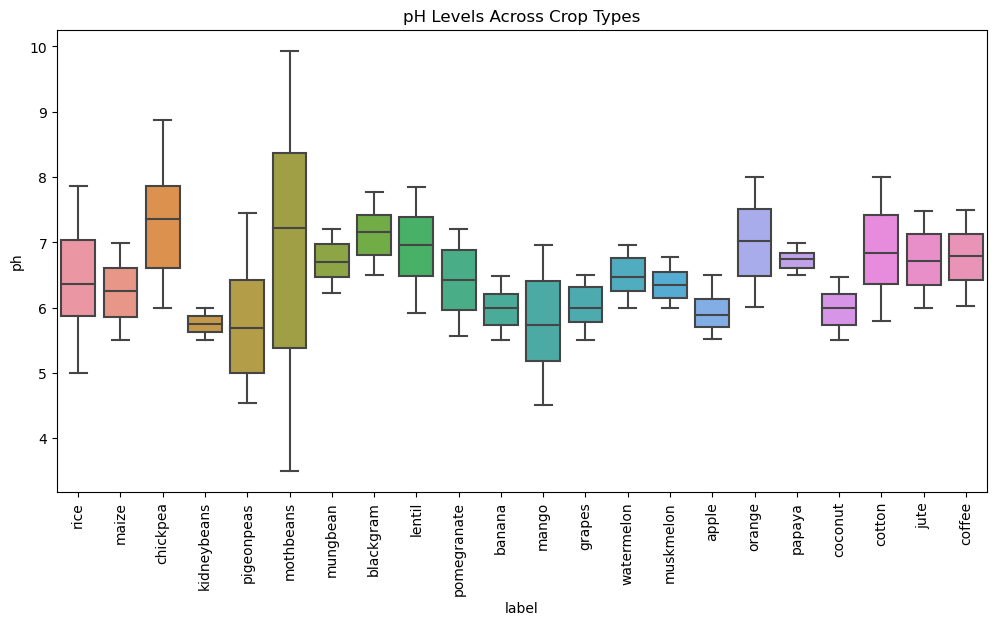

In [ ]:
# Boxplot of pH values across different crops
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='ph', data=df)
plt.xticks(rotation=90)
plt.title('pH Levels Across Crop Types')
plt.show()

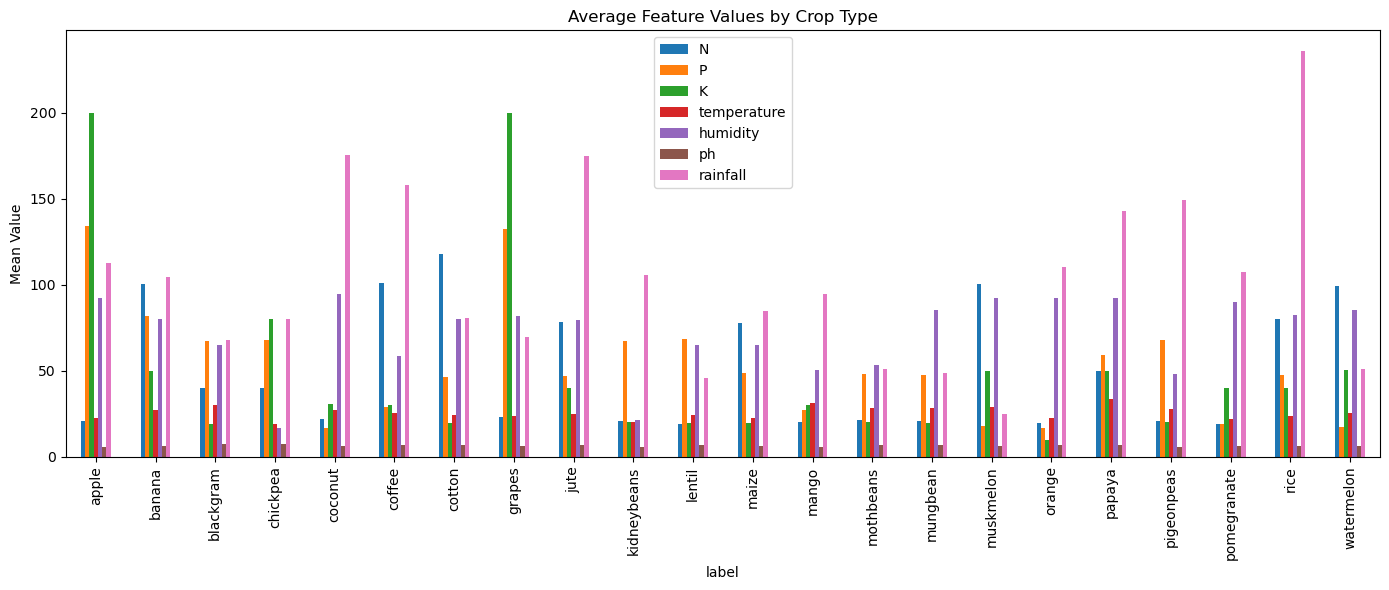

In [ ]:
# Group by crop label and plot the mean values of features
grouped = df.groupby('label').mean().reset_index()
grouped.set_index('label').plot(kind='bar', figsize=(14,6))
plt.title('Average Feature Values by Crop Type')
plt.ylabel('Mean Value')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

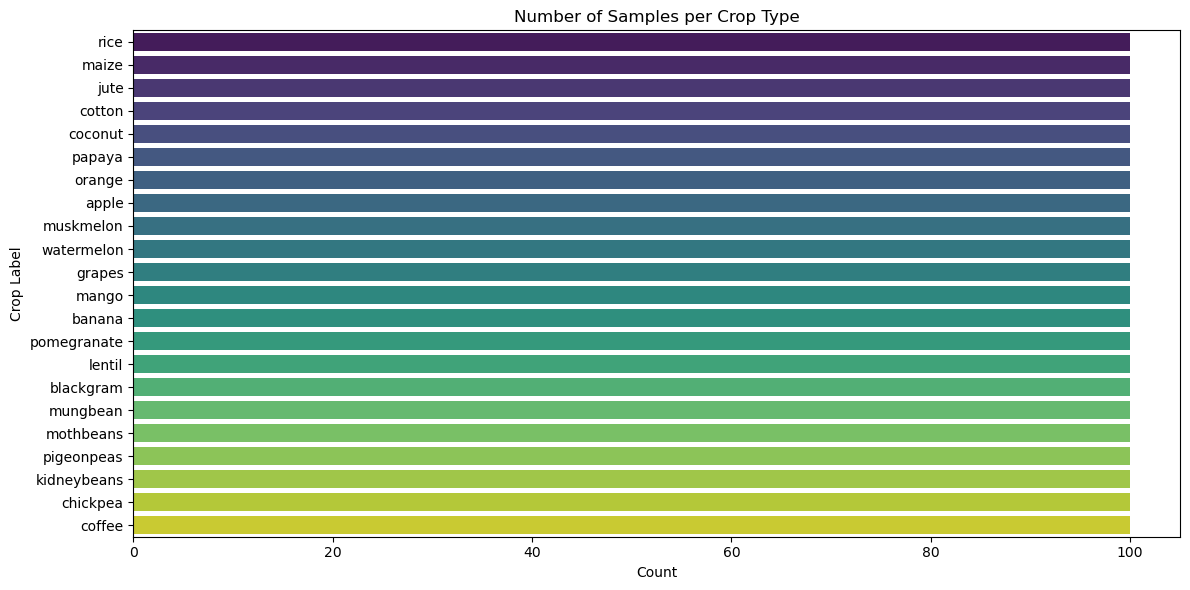

In [ ]:
# Plot count of samples available for each crop type
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Number of Samples per Crop Type')
plt.xlabel('Count')
plt.ylabel('Crop Label')
plt.tight_layout()
plt.show()

In [ ]:
# Print the min and max values for each numerical feature
for col in df.select_dtypes(include=np.number).columns:
    print(f"{col}: Min = {df[col].min()}, Max = {df[col].max()}")

N: Min = 0, Max = 140
P: Min = 5, Max = 145
K: Min = 5, Max = 205
temperature: Min = 8.825674745, Max = 43.67549305
humidity: Min = 14.25803981, Max = 99.98187601
ph: Min = 3.504752314, Max = 9.93509073
rainfall: Min = 20.21126747, Max = 298.5601175


In [ ]:
# Define feature set and target variable
import pandas as pd
df=pd.read_csv("Crop_recommendation.csv")
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

In [ ]:
# Normalize features for better performance in distance-based models
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Encode crop labels to numerical format
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [8]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [9]:
# Use cosine similarity for recommending crops based on features
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(X_scaled)

In [10]:
# Return top 5 crops similar to a given sample based on cosine similarity
def recommend_similar_crops(index, top_n=5):
    sim_scores = list(enumerate(similarity_matrix[index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    crop_indices = [i[0] for i in sim_scores]
    return df['label'].iloc[crop_indices].values

In [11]:
# Test the content-based crop recommender
sample_index = 0
print(f"Input Crop: {df['label'][sample_index]}")
print("Recommended Similar Crops:", recommend_similar_crops(sample_index))

Input Crop: rice
Recommended Similar Crops: ['rice' 'jute' 'rice' 'rice' 'rice']


In [13]:
# Build and train a classifier (Random Forest used here)
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [14]:
# Predict crops and convert encoded output back to original label
y_pred = rf_model.predict(X_test)
decoded_preds = le.inverse_transform(y_pred)

In [15]:
# Combine similarity and ML predictions
def hybrid_recommender(input_features):
    input_scaled = scaler.transform([input_features])
    predicted_crop = le.inverse_transform(rf_model.predict(input_scaled))[0]
    input_index = cosine_similarity(input_scaled, X_scaled).argmax()
    similar_crops = recommend_similar_crops(input_index)
    return predicted_crop, similar_crops

In [16]:
# Test hybrid recommender with a sample input
sample_input = X.iloc[10].values
predicted_crop, similar_crops = hybrid_recommender(sample_input)
print(f"Predicted Crop: {predicted_crop}")
print(f"Recommended Alternatives: {similar_crops}")

c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted Crop: rice
Recommended Alternatives: ['rice' 'rice' 'rice' 'rice' 'rice']


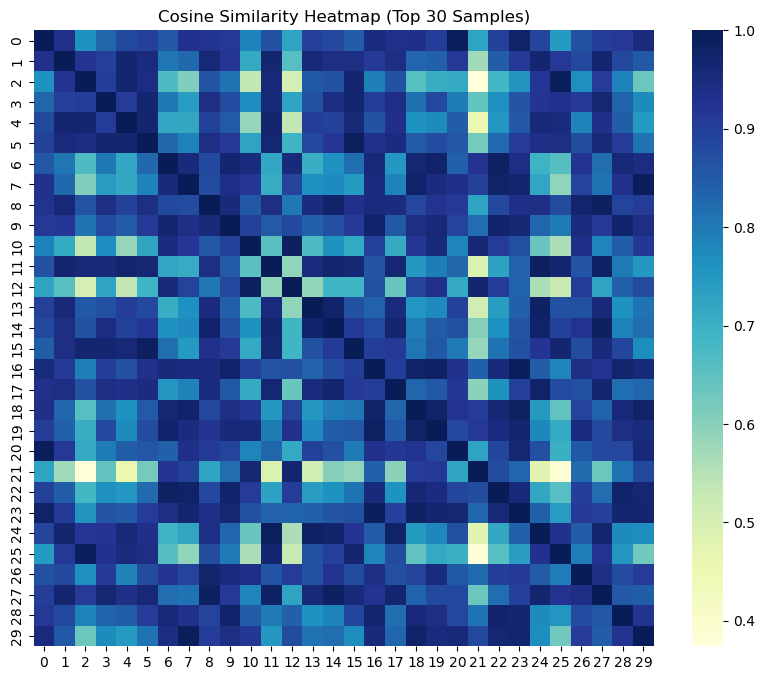

In [17]:
# Plot similarity heatmap (sample for first 30 entries)
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix[:30, :30], cmap='YlGnBu')
plt.title("Cosine Similarity Heatmap (Top 30 Samples)")
plt.show()

In [19]:
# Print ML model accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Classifier Accuracy: {accuracy:.2f}")

Random Forest Classifier Accuracy: 0.99


In [20]:
# Compare true vs predicted crop types (first 20)
print("Actual:", le.inverse_transform(y_test[:20]))
print("Predicted:", decoded_preds[:20])

Actual: ['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'maize' 'papaya' 'muskmelon']
Predicted: ['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'maize' 'papaya' 'muskmelon']


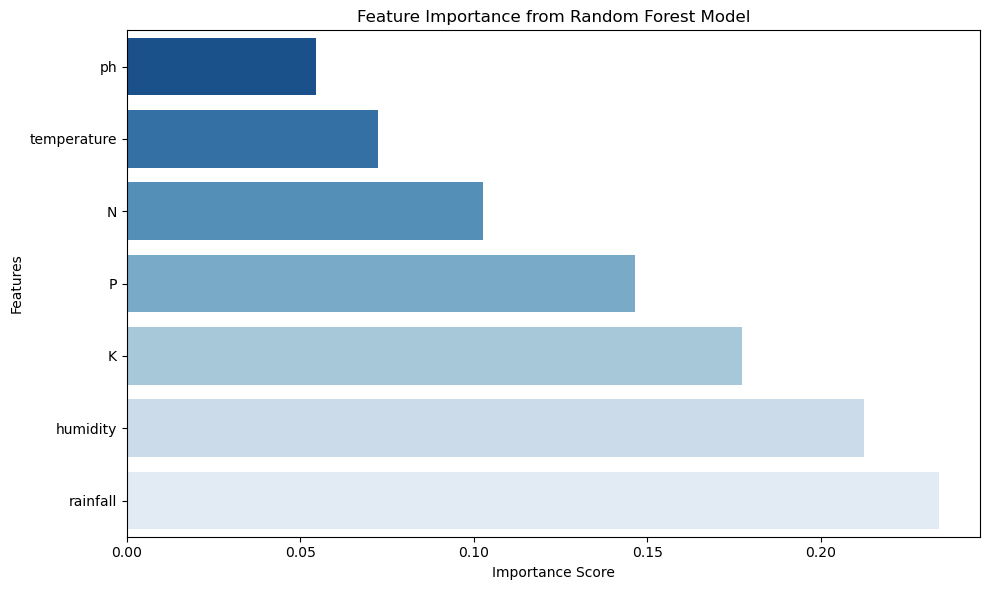

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already have the trained Random Forest model
# and that X_train or X contains the feature names

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a pandas series for visualization
features = X.columns  # replace X with your actual DataFrame used for training
importance_series = pd.Series(feature_importances, index=features)

# Sort the features by importance
importance_series_sorted = importance_series.sort_values(ascending=True)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_series_sorted, y=importance_series_sorted.index, palette='Blues_r')
plt.title("Feature Importance from Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.99772727 0.98863636 0.99772727 0.99545455 0.99090909]
Average accuracy: 0.9940909090909091


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
# Train and evaluate Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Evaluation metrics
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_log, average='weighted'))

# Crop recommendation test
print("Actual:", le.inverse_transform(y_test[:20]))
print("Predicted:", le.inverse_transform(y_pred_log[:20]))

Logistic Regression Metrics:
Accuracy: 0.9636363636363636
Precision: 0.9644420567548909
Recall: 0.9636363636363636
F1 Score: 0.9635115059268676
Actual: ['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'maize' 'papaya' 'muskmelon']
Predicted: ['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'maize' 'papaya' 'muskmelon']


In [28]:
# Train and evaluate KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# Evaluation metrics
print("KNN Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_knn, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_knn, average='weighted'))

# Crop recommendation test
print("Actual:", le.inverse_transform(y_test[:20]))
print("Predicted:", le.inverse_transform(y_pred_knn[:20]))

KNN Metrics:
Accuracy: 0.9568181818181818
Precision: 0.9628976143584398
Recall: 0.9568181818181818
F1 Score: 0.9567492608232794
Actual: ['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'maize' 'papaya' 'muskmelon']
Predicted: ['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'cotton' 'papaya' 'muskmelon']


In [29]:
from sklearn.tree import DecisionTreeClassifier

# Train and evaluate Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Evaluation metrics
print("Decision Tree Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_dt, average='weighted'))

# Crop recommendation test
print("Actual:", le.inverse_transform(y_test[:20]))
print("Predicted:", le.inverse_transform(y_pred_dt[:20]))

Decision Tree Metrics:
Accuracy: 0.9863636363636363
Precision: 0.9868759018759019
Recall: 0.9863636363636363
F1 Score: 0.9863338104589819
Actual: ['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'maize' 'papaya' 'muskmelon']
Predicted: ['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'maize' 'papaya' 'muskmelon']


In [30]:
# Import necessary libraries
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Optionally: Encode labels if not already done
# le = LabelEncoder()
# y_train = le.fit_transform(y_train)
# y_test = le.transform(y_test)

# Option 1: Gradient Boosting (optimized for speed)
gb_model = GradientBoostingClassifier(
    n_estimators=50,      # Reduce number of boosting rounds
    max_depth=3,          # Limit tree depth
    learning_rate=0.1,    # Standard learning rate
    subsample=0.8,        # Use a subset of data for each tree
    random_state=42
)

try:
    gb_model.fit(X_train, y_train)
    y_pred_gb = gb_model.predict(X_test)

    # Evaluation metrics
    print("Gradient Boosting Metrics:")
    print("Accuracy:", accuracy_score(y_test, y_pred_gb))
    print("Precision:", precision_score(y_test, y_pred_gb, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred_gb, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred_gb, average='weighted'))

    # Crop recommendation test output
    print("\nCrop Recommendation (First 20 Samples):")
    print("Actual:   ", le.inverse_transform(y_test[:20]))
    print("Predicted:", le.inverse_transform(y_pred_gb[:20]))

except KeyboardInterrupt:
    print("Training was manually interrupted.")

# Option 2: Faster training using HistGradientBoostingClassifier (if supported)
# Uncomment to use instead:
# hgb_model = HistGradientBoostingClassifier(random_state=42)
# hgb_model.fit(X_train, y_train)
# y_pred_hgb = hgb_model.predict(X_test)

Gradient Boosting Metrics:
Accuracy: 0.990909090909091
Precision: 0.9914276695526695
Recall: 0.990909090909091
F1 Score: 0.9909350005002179

Crop Recommendation (First 20 Samples):
Actual:    ['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'maize' 'papaya' 'muskmelon']
Predicted: ['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil' 'blackgram' 'coconut' 'pomegranate'
 'jute' 'coconut' 'pomegranate' 'apple' 'maize' 'papaya' 'muskmelon']


In [31]:
# Compare all models on accuracy, precision, recall, F1
models = {
    'Random Forest': (rf_model, y_pred),
    'Logistic Regression': (log_model, y_pred_log),
    'KNN': (knn_model, y_pred_knn),
    'Decision Tree': (dt_model, y_pred_dt),
    'Gradient Boosting': (gb_model, y_pred_gb)
}

print("{:<20} {:<10} {:<10} {:<10} {:<10}".format('Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'))
for name, (model, pred) in models.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted')
    rec = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')
    print(f"{name:<20} {acc:<10.2f} {prec:<10.2f} {rec:<10.2f} {f1:<10.2f}")

Model                Accuracy   Precision  Recall     F1 Score  
Random Forest        0.99       0.99       0.99       0.99      
Logistic Regression  0.96       0.96       0.96       0.96      
KNN                  0.96       0.96       0.96       0.96      
Decision Tree        0.99       0.99       0.99       0.99      
Gradient Boosting    0.99       0.99       0.99       0.99      


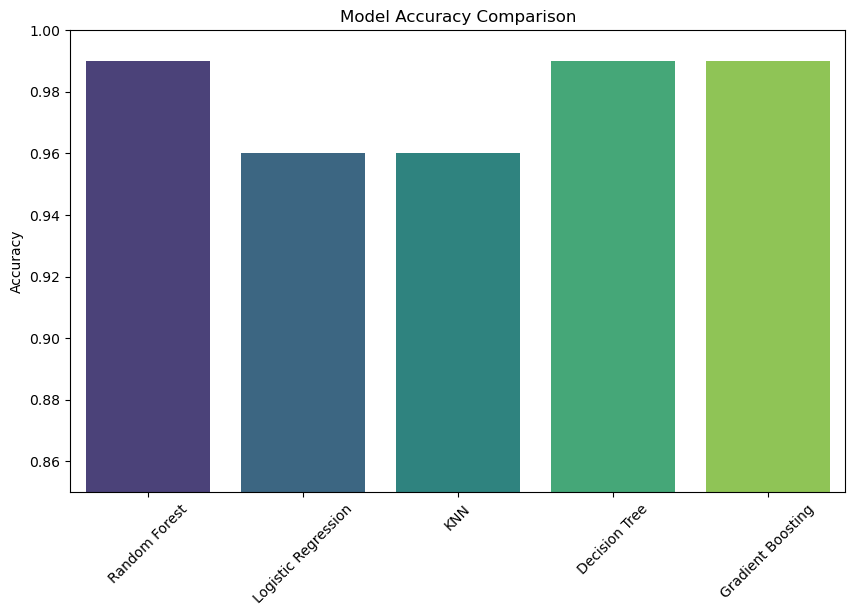

In [33]:
# Plot Accuracy of all models
model_names = ['Random Forest', 'Logistic Regression', 'KNN', 'Decision Tree', 'Gradient Boosting']
accuracies = [0.99, 0.96, 0.96, 0.99, 0.99]

plt.figure(figsize=(10,6))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=45)
plt.show()

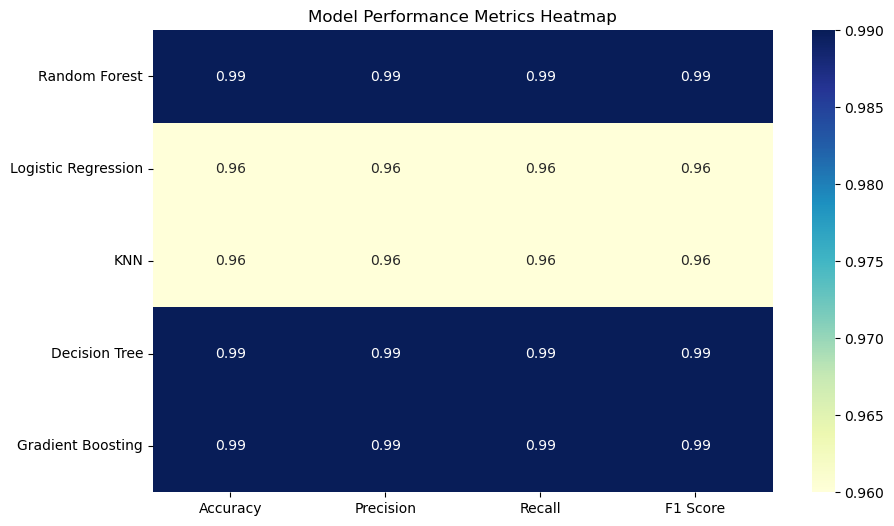

In [35]:
# Combined heatmap for all metrics
precisions = [0.99, 0.96, 0.96, 0.99, 0.99]
recalls = [0.99, 0.96, 0.96, 0.99, 0.99]
f1_scores = [0.99, 0.96, 0.96, 0.99, 0.99]
metrics_df = pd.DataFrame({
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1_scores
}, index=model_names)

plt.figure(figsize=(10,6))
sns.heatmap(metrics_df, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Model Performance Metrics Heatmap')
plt.show()

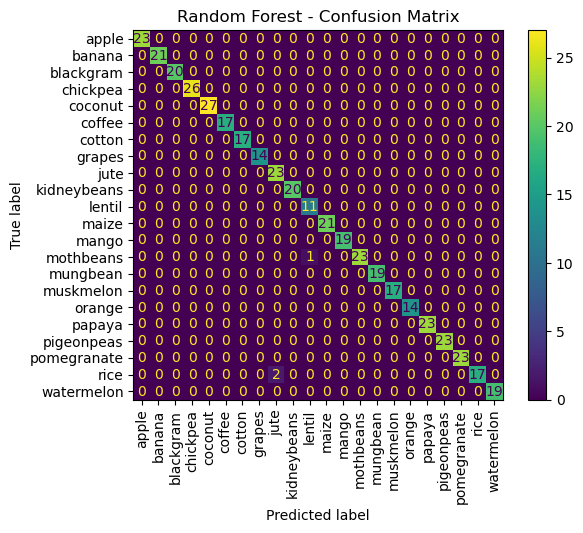

In [36]:
# Confusion matrix for best model (Random Forest)
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, display_labels=le.classes_, xticks_rotation=90)
plt.title("Random Forest - Confusion Matrix")
plt.show()

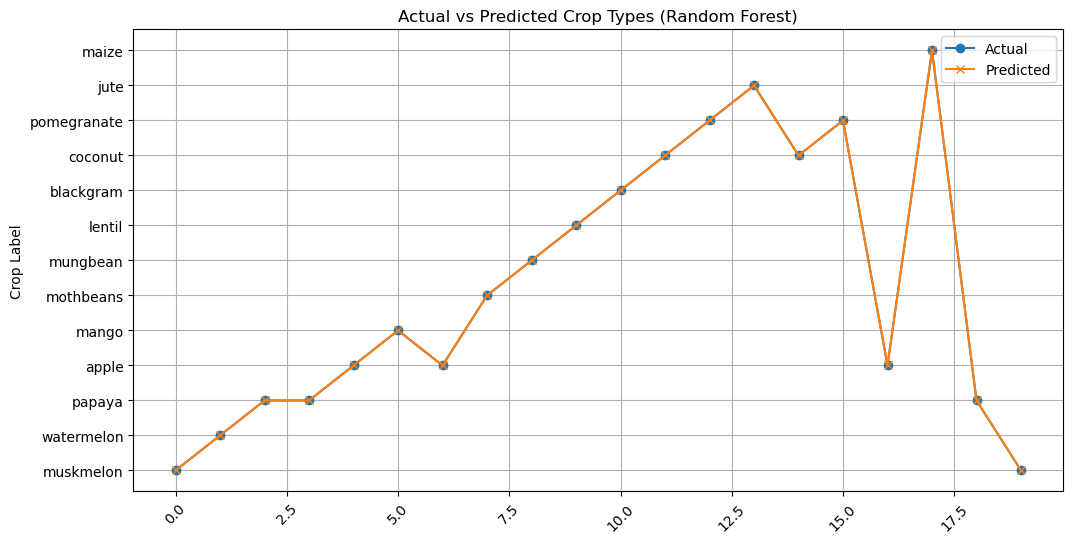

In [37]:
# Plot actual vs predicted for first 20 samples
actual_labels = le.inverse_transform(y_test[:20])
predicted_labels = le.inverse_transform(y_pred[:20])

plt.figure(figsize=(12,6))
plt.plot(actual_labels, label='Actual', marker='o')
plt.plot(predicted_labels, label='Predicted', marker='x')
plt.xticks(rotation=45)
plt.title("Actual vs Predicted Crop Types (Random Forest)")
plt.ylabel("Crop Label")
plt.legend()
plt.grid(True)
plt.show()

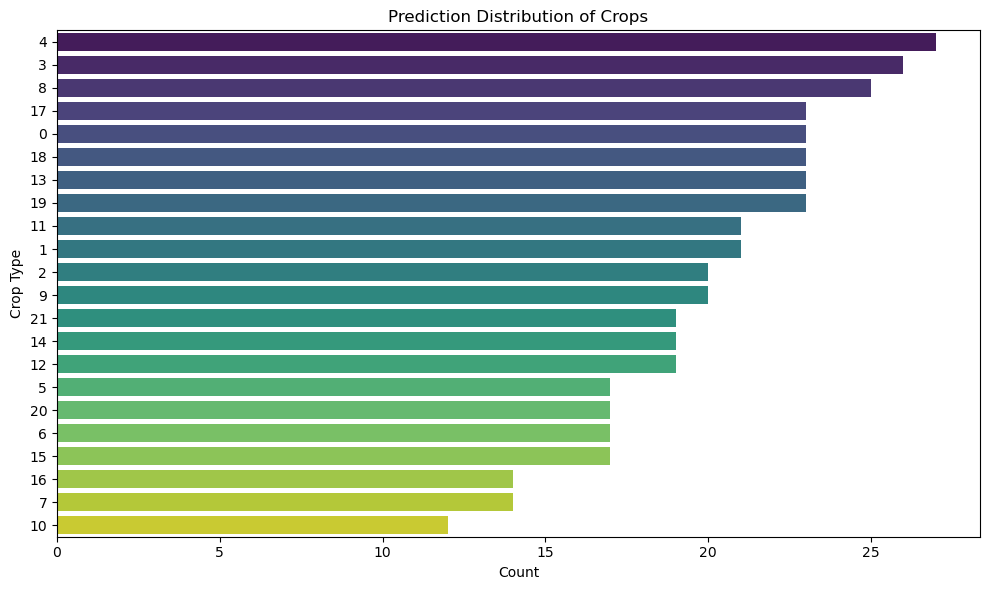

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming y_pred contains the model's predicted crop labels
# and y_test is your true labels

# Convert predictions to a Pandas Series for plotting
pred_series = pd.Series(y_pred, name="Predicted Crop")

# Create a count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=pred_series.to_frame(), y="Predicted Crop", order=pred_series.value_counts().index, palette="viridis")
plt.title("Prediction Distribution of Crops")
plt.xlabel("Count")
plt.ylabel("Crop Type")
plt.tight_layout()
plt.show()

In [39]:
# Function to recommend crop using Random Forest
def recommend_crop(input_features):
    input_array = np.array(input_features).reshape(1, -1)
    prediction = rf_model.predict(input_array)
    predicted_crop = le.inverse_transform(prediction)[0]
    return predicted_crop

In [40]:
# Example test for crop recommendation
sample_input = [90, 40, 40, 25.0, 80.0, 6.5, 200.0]  # N, P, K, temp, humidity, pH, rainfall
recommended_crop = recommend_crop(sample_input)
print("Recommended Crop:", recommended_crop)


Recommended Crop: apple
